In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=10, n_features=5, n_informative=5, n_targets=1, random_state=42)

In [3]:
X

array([[-0.46947439,  1.57921282,  0.54256004,  0.76743473, -0.23413696],
       [-1.42474819, -0.2257763 , -0.54438272,  0.0675282 ,  1.46564877],
       [-0.60063869, -1.15099358, -0.29169375,  0.37569802,  0.11092259],
       [-0.90802408, -1.01283112, -1.4123037 ,  0.31424733, -0.56228753],
       [ 1.52302986, -0.1382643 , -0.23415337,  0.64768854,  0.49671415],
       [-0.3011037 ,  0.17136828, -1.47852199, -0.11564828,  0.73846658],
       [-1.91328024, -0.46572975, -1.72491783,  0.24196227, -0.46341769],
       [-1.05771093,  1.85227818,  0.82254491, -0.01349722, -0.60170661],
       [ 0.34361829, -0.46063877, -1.76304016,  1.05712223, -0.71984421],
       [-1.32818605,  0.2088636 ,  0.19686124, -1.95967012, -1.22084365]])

In [4]:
y

array([ 124.67279536, -179.5999463 , -169.77048128, -285.50639044,
        132.9604    , -120.60188828, -364.11253914,   99.14556097,
       -141.45435129, -130.93357704])

In [28]:
class MeraBatchGD:
  def __init__(self, iters, lr):
    self.w = None
    self.b = None
    self.iters = iters
    self.lr = lr
    self.loss_record = []

  def fit(self, X, y):

    # take samples, features
    # initialize w = 0, and b = 0

    samples,features = X.shape
    self.w = np.zeros(features)
    self.b = 0

    # training Loop
    for i in range(self.iters):

      # y_pred
      # residual
      # mse_loss (not needed though)
      # w_slope and b_slope
      # w and b -> update
      # loss_record -> append

      y_pred = np.dot(X, self.w) + self.b

      residual = y-y_pred

      mse_loss = np.mean((y-y_pred)**2)

      slope_w = -2/samples * np.dot(X.T , residual)
      slope_b = -2/samples * np.sum(residual)

      self.w = self.w - self.lr * slope_w
      self.b = self.b - self.lr * slope_b

      self.loss_record.append(mse_loss)
      if (i == self.iters - 1):
        print(f"MSE LOSS = {mse_loss}")
      elif (i == 0 or i%10 == 0):
        print(f"MSE LOSS = {mse_loss}")

      # In this case, the entire X and Y is used,
      # in Y_pred -> Whole X has gotten => much pressure in the memory to keep the Whole X in the memory for that instance

In [57]:
bgd = MeraBatchGD(iters = 100, lr = 0.1)

In [58]:
bgd.fit(X,y)

MSE LOSS = 36991.936384800705
MSE LOSS = 325.40678063168116
MSE LOSS = 57.80201458629138
MSE LOSS = 17.375898812254682
MSE LOSS = 5.654342143641683
MSE LOSS = 1.8650297263298843
MSE LOSS = 0.6197366426952676
MSE LOSS = 0.20769355541514053
MSE LOSS = 0.07039084464960109
MSE LOSS = 0.02421499551032153
MSE LOSS = 0.009421325583617069


In [59]:
bgd.w

array([98.6026833 , 80.17776331, 77.28207754,  7.5859391 , 14.05281039])

In [60]:
class MeraStochasticGD:
  def __init__(self, epochs, lr):
    self.w = None
    self.b = None
    self.epochs = epochs
    self.lr = lr
    self.loss_record = []

  def fit(self, X, y):
    # just like batch GD
    samples, features = X.shape
    self.w = np.zeros(features)
    self.b = 0

    # thier are two loops
    # one for epochs -> How many times does it sees all the datapoints in dataset
    # one for samples -> loop for seeing all the datapoints in dataset

    for epoch in range(self.epochs):
      for i in range(samples):

        # just two steps to initialize
        # idx
        # xi and yi
        # and keep xi and yi, wherever thier is X, y

        idx = np.random.randint(0, samples)
        xi = X[idx]
        yi = y[idx]

        # after this all is same

        y_pred = np.dot(xi, self.w) + self.b
        residual = yi - y_pred

        mse_loss = (yi-y_pred)**2

        slope_w = -2 * xi * residual
        slope_b = -2 * residual

        self.w = self.w - self.lr * slope_w
        self.b = self.b - self.lr * slope_b

        self.loss_record.append(mse_loss)
        if (i == 0 or i%10 == 0):
          print(f"MSE LOSS = {mse_loss}")
        elif (i == samples - 1):
          print(f"MSE LOSS = {mse_loss}")



In [61]:
sgd = MeraStochasticGD(epochs = 100, lr = 0.1)

In [62]:
sgd.fit(X,y)

MSE LOSS = 17143.60159586747
MSE LOSS = 138.26697944384813
MSE LOSS = 2363.955450814484
MSE LOSS = 91.62853426641242
MSE LOSS = 61.32153484464119
MSE LOSS = 1.683184339443875
MSE LOSS = 546.7289273161306
MSE LOSS = 24.281941540773364
MSE LOSS = 374.26133357841013
MSE LOSS = 0.0039042759974250874
MSE LOSS = 0.12397979747623362
MSE LOSS = 6.559561174387216
MSE LOSS = 2.7862588065284646
MSE LOSS = 4.1465733577929
MSE LOSS = 18.36018004217598
MSE LOSS = 0.05360725050313441
MSE LOSS = 4.776159971362796
MSE LOSS = 0.03694261941889988
MSE LOSS = 0.10440973235202346
MSE LOSS = 0.22042366981858535
MSE LOSS = 0.0005953609744290307
MSE LOSS = 0.17448189102465742
MSE LOSS = 0.29597338447202187
MSE LOSS = 0.015673653082837805
MSE LOSS = 0.0028412054008292898
MSE LOSS = 0.006594657978097726
MSE LOSS = 0.06963030117726894
MSE LOSS = 0.015392363333242932
MSE LOSS = 0.025044574248560714
MSE LOSS = 0.0018783419959662506
MSE LOSS = 0.004796061466860836
MSE LOSS = 0.00130905234193376
MSE LOSS = 0.00437074

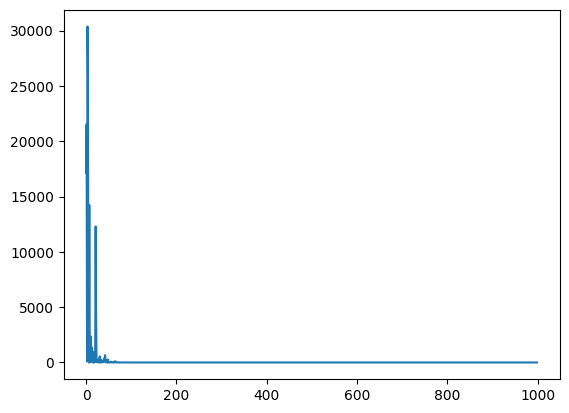

In [63]:
plt.plot(sgd.loss_record)


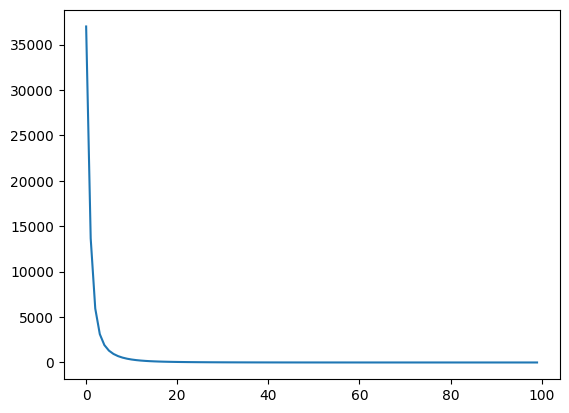

In [64]:
plt.plot(bgd.loss_record)

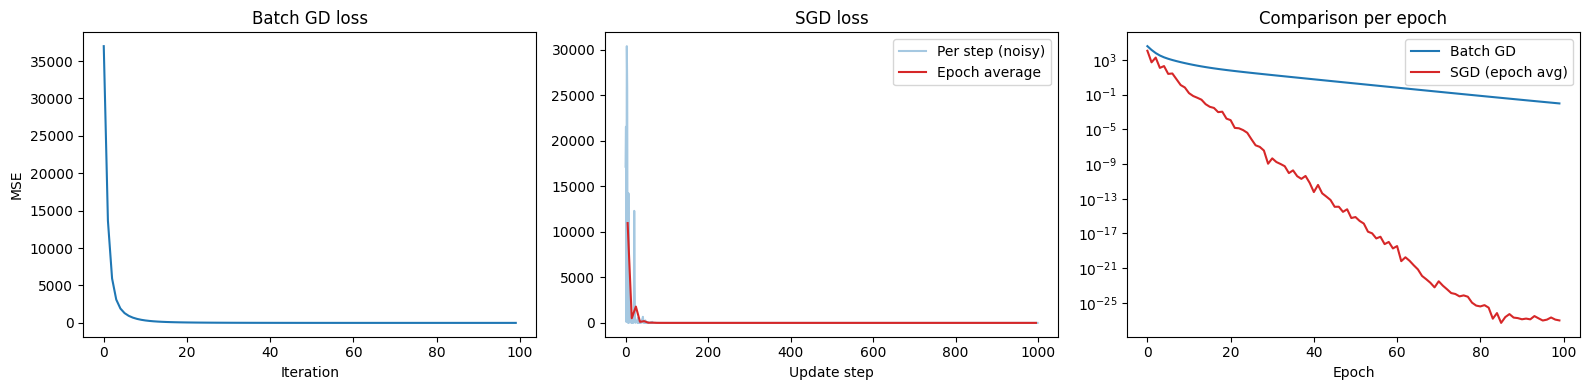

In [65]:
# @title
n = X.shape[0]                                   # number of samples
bgd_loss = np.array(bgd.loss_record)             # 1 value per iteration (= 1 full pass)
sgd_step = np.array(sgd.loss_record)             # 1 value per single-sample update
sgd_epoch = sgd_step.reshape(-1, n).mean(axis=1) # average the loss within each epoch

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(bgd_loss, color="tab:blue")
ax[0].set_title("Batch GD loss")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("MSE")

ax[1].plot(sgd_step, alpha=0.4, label="Per step (noisy)")
ax[1].plot(np.arange(len(sgd_epoch)) * n + n/2, sgd_epoch, color="tab:red", label="Epoch average")
ax[1].set_title("SGD loss")
ax[1].set_xlabel("Update step")
ax[1].legend()

ax[2].plot(bgd_loss, label="Batch GD", color="tab:blue")
ax[2].plot(sgd_epoch, label="SGD (epoch avg)", color="tab:red")
ax[2].set_yscale("log")
ax[2].set_title("Comparison per epoch")
ax[2].set_xlabel("Epoch")
ax[2].legend()

plt.tight_layout()
plt.show()

In [70]:
class MeraMiniBatchGD :
  def __init__(self, epochs, lr, batch_size):
    self.w = None
    self.b = None
    self.epochs = epochs
    self.lr = lr
    self.loss_record = []

    # One new class variable
    self.batch_size = batch_size

  def fit(self, X, y):
    samples, features = X.shape
    self.w = np.zeros(features)
    self.b = 0

    for epoch in range(self.epochs):

      # shuffle the samples and then form batches
      # => batches differ in each pass
      idxs = np.random.permutation(samples)
      x_shuf = X[idxs]
      y_shuf = y[idxs]

      # loop over batches
      for start in range(0, samples,self.batch_size):
        x_batch = x_shuf[start : start + self.batch_size]
        y_batch = y_shuf[start : start + self.batch_size]

        # consider that by the end the batch size will get smaller,
        # so get the actual batch size as well
        m = x_batch.shape[0]


        # after this everything is same
        y_pred = np.dot(x_batch, self.w) + self.b
        residual = y_batch - y_pred

        # mse_loss = (y_batch-y_pred)**2

        slope_w = -2/m * np.dot(x_batch.T, residual)
        slope_b = -2/m * np.sum(residual)

        self.w = self.w - self.lr * slope_w
        self.b = self.b - self.lr * slope_b

      full_pred = np.dot(X, self.w) + self.b
      mse_loss = np.mean((y - full_pred)**2)
      self.loss_record.append(mse_loss)

      if (epoch == self.epochs - 1):
        print(f"MSE LOSS = {mse_loss}")
      elif (epoch == 0 or epoch%10 == 0):
        print(f"MSE LOSS = {mse_loss}")




In [71]:
mbgd = MeraMiniBatchGD(epochs = 100, lr = 0.1, batch_size = 5)

In [72]:
mbgd.fit(X,y)

MSE LOSS = 5501.935477934566
MSE LOSS = 45.95760273131508
MSE LOSS = 4.186068127089503
MSE LOSS = 0.41394729762517757
MSE LOSS = 0.04409349656283892
MSE LOSS = 0.00546887830527589
MSE LOSS = 0.0007765622923111483
MSE LOSS = 0.00013059284387954877
MSE LOSS = 2.461022746003841e-05
MSE LOSS = 4.789401359751617e-06
MSE LOSS = 1.1659683944364416e-06


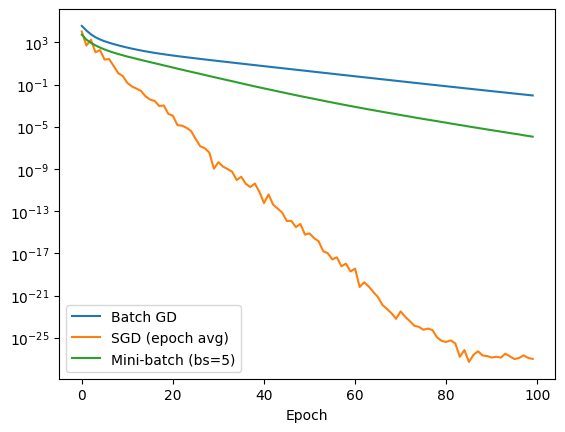

In [73]:
plt.plot(bgd.loss_record, label="Batch GD")
plt.plot(sgd_epoch, label="SGD (epoch avg)")
plt.plot(mbgd.loss_record, label="Mini-batch (bs=5)")
plt.yscale("log")
plt.xlabel("Epoch")
plt.legend()
plt.show()
